Modelo S com data augmentation com uma batch size diferente

In [6]:
# dependencies
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from keras import layers, regularizers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing import image
import numpy as np

Neste modelo, utilizamos uma implementação semelhante à do modelo base sem optuna, com alteração no tamanho do batch size (de 32 para 64), com o objetivo de analisar a diferença de resultados.

In [7]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=64) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=64)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=64)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [14]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.3),
])

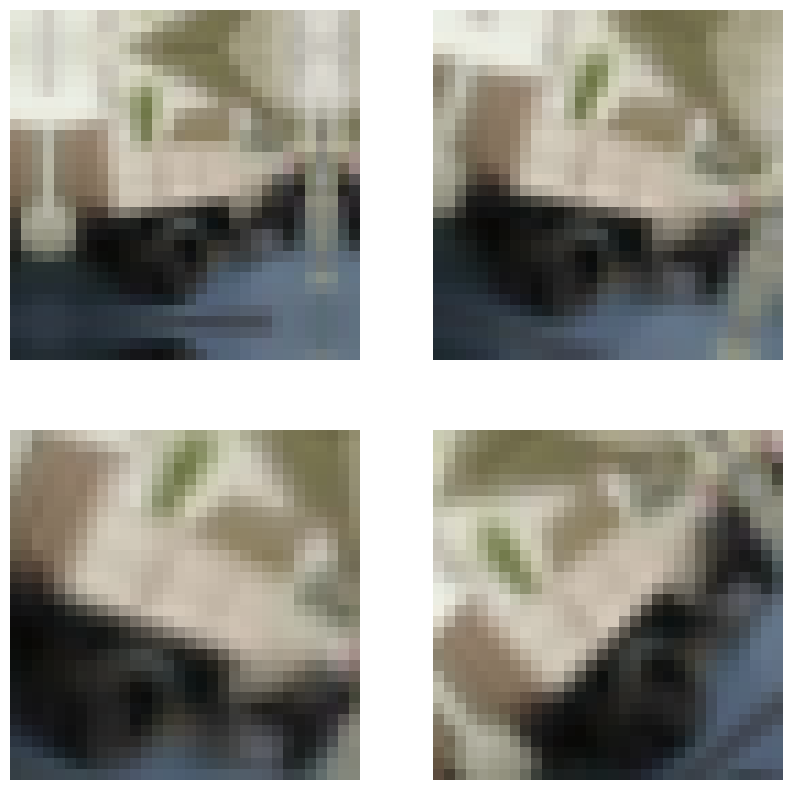

In [15]:
# apresentar 4 primeiras imagens da primeira batch
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(4):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

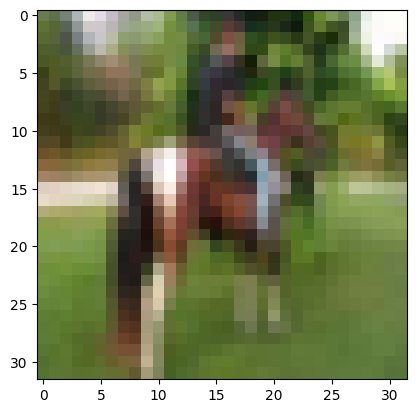

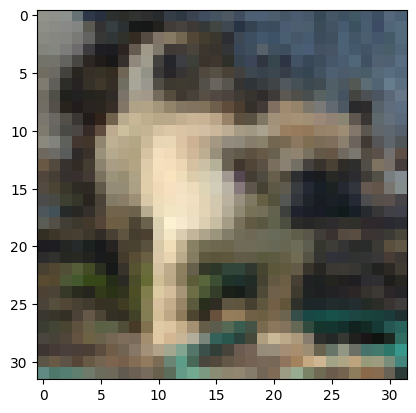

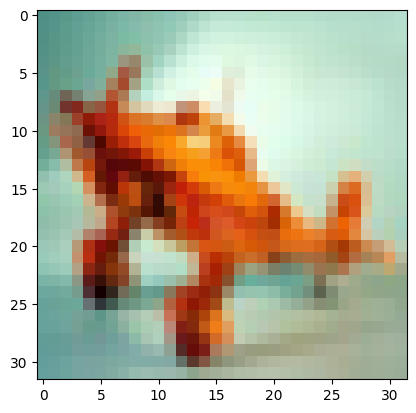

In [16]:
# import matplotlib.pyplot as plt

for data_batch, _ in train_dataset.take(1):
  for i in range(3):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

In [17]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

l2_regularizer = 0.001

x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Dropout(0.25)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(25, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 100)      │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,485 (701.11 KB)

 Trainable params: 179,485 (701.11 KB)

 Non-trainable params: 0 (0.00 B)

Ao testar a entrada de diferentes parâmetros, experimentámos a alteração do learning rate de 1e-4 para 1e-3, mas não obtivemos resultados satisfatórios, logo essa decisão foi revertida.


In [18]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [19]:
model_filename = 'model_s_sem_optuna_batch_size.keras'

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# para salvar o melhor modelo
checkpoint_callback = ModelCheckpoint(
    model_filename,
    monitor='val_acc', 
    save_best_only=True,
    mode='max',
    save_weights_only=False
)

# Training the model
history = model.fit(train_dataset, epochs=200, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])


Epoch 1/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - acc: 0.1202 - loss: 5.2598 - val_acc: 0.1971 - val_loss: 2.2858
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - acc: 0.1781 - loss: 2.2788 - val_acc: 0.2448 - val_loss: 2.0929
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - acc: 0.2254 - loss: 2.1059 - val_acc: 0.2966 - val_loss: 1.9765
Epoch 4/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - acc: 0.2608 - loss: 1.9872 - val_acc: 0.3595 - val_loss: 1.8499
Epoch 5/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - acc: 0.3098 - loss: 1.8923 - val_acc: 0.4089 - val_loss: 1.7592
Epoch 6/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - acc: 0.3553 - loss: 1.8028 - val_acc: 0.4369 - val_loss: 1.6603
Epoch 7/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - acc: 0.3944 - loss: 1.7155 - val_acc: 0.4656 - val_loss: 1.5776
Epoch 8/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - acc: 0.4216 - loss: 1.6409 - val_acc: 0.4947 - val_loss: 1.5096
Epoch 9/200
625/625 ━━━━━━━━━━━━

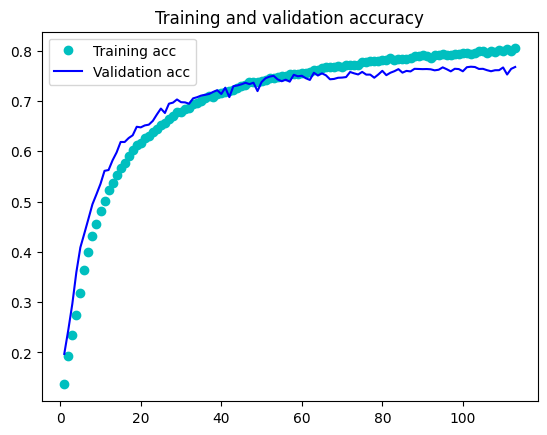

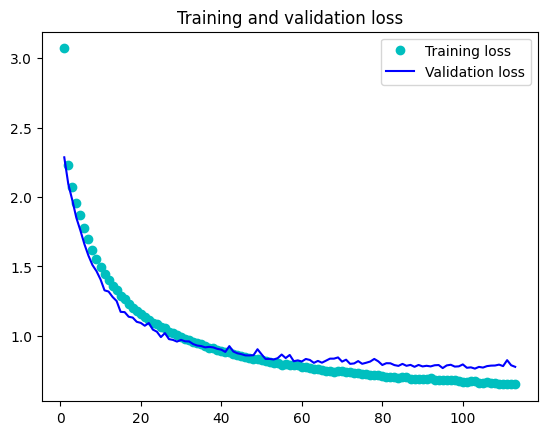

In [20]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'co', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'co', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# validation acc e validation loss é a que realmente importa

Conseguimos entender por análise do gráfico que inicialmente o modelo estava a ter um bom comportamento, mas, perto da época 50, embora os valores da validation accuracy estivessem a aumentar, os de treino aumentavam ainda mais, pelo que se pode concluir que começou a fazer overfitting.

Como referido, ao tentar alterar os parâmetros batch_size (de 32 para 64) e learning_rate (de 1e-4 para 1e-3) obtivemos os seguintes resultados:

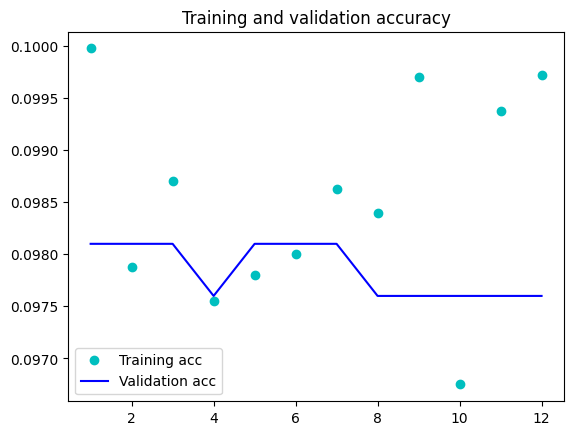
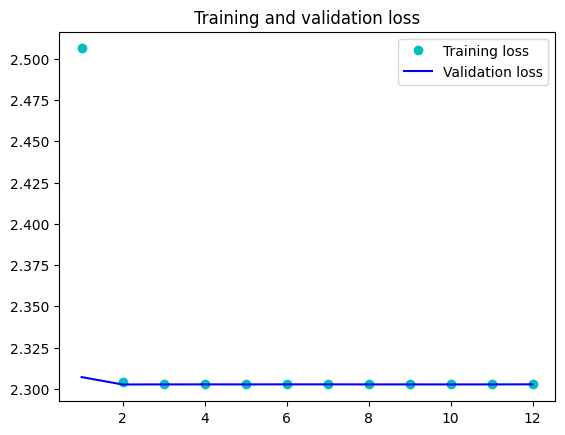

In [8]:
test_loss, test_accuracy = loaded_model.evaluate(test_dataset)
print(f'Validation Accuracy of the Best Model: {test_accuracy}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - acc: 0.7795 - loss: 0.7467
Validation Accuracy of the Best Model: 0.7746999859809875


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━

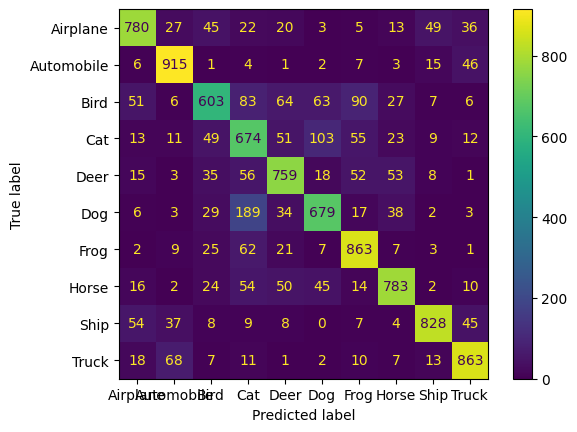

In [11]:
from sklearn import metrics

import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the model
model_filename = 'model_s_sem_optuna_batch_size.keras'
loaded_model = tf.keras.models.load_model(model_filename)

y_true = []
y_pred = []

# Iterate over the test dataset to get predictions and true labels
for images, labels in test_dataset:
    preds = loaded_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the confusion matrix
conf_mat = metrics.confusion_matrix(y_true, y_pred)

# display matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()


Por análise da matriz de confusão, entende-se que, apesar do overfitting analisado, o modelo apresenta resultados maioritariamente satisfatórios, com exceção de algumas classes que apresentam uma taxa de acerto menor. 
A destacar são as classes bird e cat, que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 603 e 674, respetivamente. Outro ponto a destacar é que a classe pela qual 'cat' é mais confundida é a classe 'dog' e vice-versa, revelando que o modelo tem dificuldade em distinguir entre estas duas classes. 
As classes com maior taxa de acerto são 'frog', 'truck' e 'automobile', com 863, 863 e 915 imagens corretamente classificadas, respetivamente.

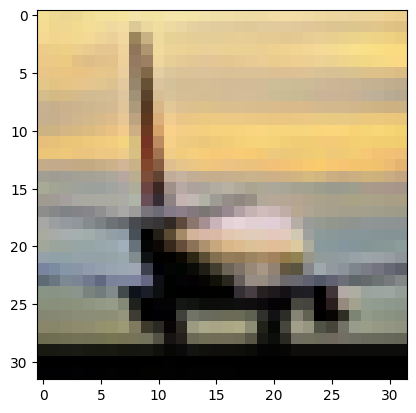

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Model predicts:  airplane
Result:  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [22]:
img = tf.keras.preprocessing.image.load_img('test/000_airplane/aeroplane_s_000002.png', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())